<font color='Blue'><b> Привет, Олег! Можешь обращаться ко мне на «ты». Спасибо за комментарии, я доработал проект, чтобы  исправить недочёты и добавить недостающие элементы. Ниже — обновлённая версия тетрадки с учётом всех замечаний ревьюера. Я структурировал проект, добавил необходимые элементы, исправил оформление графиков, фильтрацию заглушек и анализ по годам для фильмов с господдержкой, а также сделал более полный общий вывод.</b> </font>

## Исследование данных о российском кинопрокате



Цель исследования — изучить рынок российского кинопроката, выявить текущие тренды и оценить интерес зрителей к фильмам с государственной поддержкой. Заказчик — Министерство культуры РФ. Используются данные из реестра прокатных удостоверений и сведений о сборах в кинотеатрах.

***План исследования***

1. **Загрузка и объединение данных:** Объединить датасеты mkrf_movies.csv и mkrf_shows.csv по столбцу puNumber, сохраняя все записи из mkrf_movies.



2. **Предобработка данных:**

 - Проверить и скорректировать типы данных.
 - Обработать пропуски с учётом их природы.
 - Устранить дубликаты.
 - Исправить проблемы в категориальных столбцах.
 - Проверить количественные значения на аномалии.
 - Добавить новые столбцы для анализа.

3. **Исследовательский анализ:**
 - Проанализировать количество фильмов в прокате по годам и долю с данными о сборах.
 - Изучить динамику кассовых сборов.
 - Оценить влияние возрастного ограничения на сборы (2015–2019).

4. **Анализ фильмов с господдержкой:**
 - Исследовать объём поддержки, окупаемость, рейтинги и жанры по годам.

5. **Общий вывод:** Обобщить результаты и предложить рекомендации.

### Шаг 1. Откройте файлы с данными и объедините их в один датафрейм. 

Объединим датасеты **```mkrf_movies.csv```** и **```mkrf_shows.csv```** так, чтобы все фильмы из **```mkrf_movies```** вошли в итоговый датафрейм. Ключ для объединения — столбец puNumber.

In [1]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загрузка данных
movies = pd.read_csv('/datasets/mkrf_movies.csv')
shows = pd.read_csv('/datasets/mkrf_shows.csv')

In [3]:
# Изучение структуры данных
print("Информация о movies:")
display(movies.info())
print("\nПервые строки movies:")
display(movies.head())

Информация о movies:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-nul

None


Первые строки movies:


,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [4]:
print("\nИнформация о shows:")
display(shows.info())
print("\nПервые строки shows:")
display(shows.head())


Информация о shows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


None


Первые строки shows:


,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08


In [5]:
# Проверка типов данных столбца puNumber
print("Типы данных puNumber:")
print("movies:", movies['puNumber'].dtype)
print("shows:", shows['puNumber'].dtype)

Типы данных puNumber:
movies: object
shows: int64


In [6]:
# Приведение puNumber к строковому типу
movies['puNumber'] = movies['puNumber'].astype(str).str.strip()
shows['puNumber'] = shows['puNumber'].astype(str).str.strip()

In [7]:
# Объединение датафреймов (left join)
df = movies.merge(shows, on='puNumber', how='left')

In [8]:
# Объединение с left merge
df = movies.merge(shows, on='puNumber', how='left')

In [9]:
# Проверка размеров
print("Размер исходного movies:", movies.shape)
print("Размер объединенного df:", df.shape)

Размер исходного movies: (7486, 15)
Размер объединенного df: (7486, 16)


<font color='Blue'><b>
Добавлен анализ датасетов с помощью .info() и .head() перед объединением, чтобы выявить возможные проблемы, включая экспоненциальный формат данных.</b></font>



**Вывод:**

- Датасеты загружены и изучены. В shows данные о сборах (box_office) представлены в числовом формате, но без экспоненциальных проблем.



- Столбец puNumber приведён к строковому типу для корректного объединения.



- Объединение выполнено с помощью left join, сохранив все строки из mkrf_movies.



- Размеры датафреймов совпадают, пропуски в box_office ожидаемы из-за неполных данных о сборах.

### Шаг 2. Предобработка данных

#### Шаг 2.1. Проверьте типы данных


Проверить и преобразовать типы данных в столбцах для удобства анализа.

In [11]:
# Проверка текущих типов данных
print("Типы данных до преобразования:")
print(df.info())

Типы данных до преобразования:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 65

In [12]:
# Преобразование даты
df['show_start_date'] = pd.to_datetime(df['show_start_date'], errors='coerce')

# Преобразование числовых столбцов
numeric_cols = ['refundable_support', 'nonrefundable_support', 'budget', 'box_office']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Преобразование рейтинга (альтернативный метод)
df['ratings'] = df['ratings'].str.replace('%', '').astype(float, errors='ignore').apply(lambda x: x/10 if x > 10 else x)

In [13]:
# Проверка результатов
print("\nТипы данных после преобразования:")
print(df.info())


Типы данных после преобразования:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7486 non-null   object             
 1   puNumber               7486 non-null   object             
 2   show_start_date        7486 non-null   datetime64[ns, UTC]
 3   type                   7486 non-null   object             
 4   film_studio            7468 non-null   object             
 5   production_country     7484 non-null   object             
 6   director               7477 non-null   object             
 7   producer               6918 non-null   object             
 8   age_restriction        7486 non-null   object             
 9   refundable_support     332 non-null    float64            
 10  nonrefundable_support  332 non-null    float64            
 11  budget               

In [14]:
# Преобразование числовых столбцов
numeric_columns = ['refundable_support', 'nonrefundable_support', 'budget', 'box_office']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

<font color='Blue'><b>
Упростил преобразование ratings с использованием метода, предложенного ревьюером, чтобы избежать сложной функции.
</b></font>

**Вывод**:

- show_start_date преобразован в datetime.



- Числовые столбцы (refundable_support, nonrefundable_support, budget, box_office) приведены к float.



- ratings преобразован в float, с учётом процентного формата.



- Категориальные столбцы оставлены строковыми.

#### Шаг 2.2. Изучите пропуски в датафрейме

Проанализировать пропуски и определить стратегию их обработки.

In [15]:
# Создание копии для контроля размера
temp = df.copy()
print("Размер до обработки:", len(temp))

Размер до обработки: 7486


In [16]:
# Подсчёт пропусков
missing = df.isna().sum()
missing_percent = (missing / len(df) * 100).round(2)
print("\nПропуски в данных:")
print(pd.DataFrame({'Пропуски': missing, 'Процент': missing_percent})[missing > 0])


Пропуски в данных:
                       Пропуски  Процент
film_studio                  18     0.24
production_country            2     0.03
director                      9     0.12
producer                    568     7.59
refundable_support         7154    95.57
nonrefundable_support      7154    95.57
budget                     7154    95.57
financing_source           7154    95.57
ratings                     967    12.92
genres                      976    13.04
box_office                 4328    57.81


In [17]:
# Заполнение пропусков в категориальных столбцах
category_cols = ['film_studio', 'production_country', 'director', 'producer', 'genres']
for col in category_cols:
    df[col] = df[col].fillna('Не указано')

# Контроль размера
print("\nРазмер после обработки:", len(df))


Размер после обработки: 7486


**Вывод:**

- Пропуски в ```box_office``` (много) оставлены, так как данные о сборах есть не для всех фильмов.
- Пропуски в ```budget```, ```refundable_support```, ```nonrefundable_support``` оставлены, так как они заполнены только для фильмов с господдержкой.
- Пропуски в категориальных столбцах (```film_studio```, ```production_country```, ```director```, ```producer```, ```genres```) заполнены значением "Неизвестно", чтобы сохранить данные для анализа.
- Пропуски в ```ratings``` оставлены, так как их заполнение может исказить анализ.
- Пропуски в ```financing_source``` связаны с отсутствием господдержки, оставлены как есть.

**Вывод**





- Пропуски в box_office, budget, refundable_support, nonrefundable_support, financing_source оставлены, так как они связаны с отсутствием данных о сборах или господдержке.



- Категориальные столбцы заполнены заглушкой «Не указано» для сохранения данных.



- Пропуски в ratings оставлены, чтобы не искажать анализ.



- Размер датасета не изменился, обработка корректна.

#### Шаг 2.3. Изучите дубликаты в датафрейме
- Проверьте, есть ли в данных дубликаты. Опишите причины, которые могли повлиять на появление дублей.

In [18]:
# Проверка полных дубликатов
print("Полных дубликатов:", df.duplicated().sum())

Полных дубликатов: 0


In [19]:
# Проверка дубликатов по puNumber
pu_duplicates = df[df['puNumber'].duplicated(keep=False)]
print("\nДубликаты по puNumber:")
print(pu_duplicates[['title', 'puNumber', 'show_start_date']])


Дубликаты по puNumber:
                                                  title   puNumber  \
4638                   Как жениться и остаться холостым  221154310   
4639  Иоанна - женщина на папском престоле /По роман...  221154310   
5067                                    Анализируй это!  221054410   
5068                                     Анализируй то!  221054410   

               show_start_date  
4638 2010-12-17 12:00:00+00:00  
4639 2010-12-17 12:00:00+00:00  
5067 2010-05-25 12:00:00+00:00  
5068 2010-05-25 12:00:00+00:00  


In [20]:
# Удаление дубликатов по puNumber
df = df.drop_duplicates(subset='puNumber', keep='first')

In [21]:
# Проверка дубликатов по названию и дате
title_date_duplicates = df[df.duplicated(subset=['title', 'show_start_date'], keep=False)]
print("\nДубликаты по title и show_start_date:")
print(title_date_duplicates[['title', 'puNumber', 'show_start_date']])


Дубликаты по title и show_start_date:
                                  title   puNumber           show_start_date
1300                          Эпидемия_  121025713 2013-10-07 12:00:00+00:00
1301                          Эпидемия_  221035513 2013-10-07 12:00:00+00:00
1475                             Оторвы  121006514 2014-04-07 12:00:00+00:00
1476                             Оторвы  221013214 2014-04-07 12:00:00+00:00
2191                Последние пять лет.  221008115 2015-03-25 12:00:00+00:00
2192                Последние пять лет.  121005715 2015-03-25 12:00:00+00:00
2752  Пингвиненок Пороро: Большие гонки  224001915 2015-04-15 12:00:00+00:00
2753  Пингвиненок Пороро: Большие гонки  124001915 2015-04-15 12:00:00+00:00
3086                          Анархисты  221003916 2016-02-03 12:00:00+00:00
3087                          Анархисты  121002316 2016-02-03 12:00:00+00:00
4042                              Бугай  224021210 2010-09-24 12:00:00+00:00
4043                              Буг

In [22]:
# Контроль размера
print("\nРазмер после удаления дубликатов:", len(df))


Размер после удаления дубликатов: 7484


**Вывод:**





- Полных дубликатов в данных нет.



- Дубликаты по ```puNumber``` найдены, что может быть связано с ошибками ввода или повторной выдачей номеров прокатных удостоверений. Удалены, оставлено первое вхождение.



- Дубликаты по ```title``` и ```show_start_date``` могут быть связаны с перевыпуском фильмов или разными прокатными удостоверениями для одного фильма (например, для разных форматов). Оставлены, так как это допустимо по условиям данных.

#### Шаг 2.4. Изучите категориальные значения

- Посмотрите, какая общая проблема встречается почти во всех категориальных столбцах;
- Исправьте проблемные значения в поле `type`.

<div id="accordion">
    <div class="card">
        <div class="card-header" id="headingThree">
            <button class="btn btn-link collapsed" data-toggle="collapse" data-target="#collapseHint_1" aria-expanded="false" aria-controls="collapseHint_1">Подсказка</button>
        </div>
        <div id="collapseHint_1" class="collapse" aria-labelledby="headingThree" data-parent="#accordion">
            <div class="card-body">
В поле <code>type</code> есть несколько значений, у которых появился пробел в начале строки. Самый простой способ их «починить» -- использовать метод <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.str.strip.html#pandas.Series.str.strip">.str.strip</a>. Этот метод удаляет все пробелы, которые встречаются в начале и в конце строки. Применяют его таким образом:<br>
<code>df['type'].str.strip()</code>
            </div>
        </div>
    </div>
</div>

In [23]:
# Проверка уникальных значений
category_cols = ['type', 'age_restriction', 'production_country', 'genres']
for col in category_cols:
    print(f"\nУникальные значения в {col}:")
    print(df[col].value_counts().head(10))

# Исправление пробелов в type
df['type'] = df['type'].str.strip()

# Проверка после исправления
print("\nУникальные значения в type после исправления:")
print(df['type'].value_counts())


Уникальные значения в type:
Художественный                4518
 Художественный               1389
Анимационный                   828
Прочие                         406
Документальный                 288
Научно-популярный               53
 Анимационный                    1
Музыкально-развлекательный       1
Name: type, dtype: int64

Уникальные значения в age_restriction:
«16+» - для детей старше 16 лет           2850
«18+» - запрещено для детей               1605
«12+» - для детей старше 12 лет           1592
«0+» - для любой зрительской аудитории     811
«6+» - для детей старше 6 лет              626
Name: age_restriction, dtype: int64

Уникальные значения в production_country:
США                     2171
Россия                  1821
СССР                     347
Франция                  301
Великобритания           257
Италия                   129
Германия                 110
США - Великобритания      88
Япония                    77
Испания                   74
Name: production_count

**Вывод**





- **Общая проблема**: В категориальных столбцах встречаются лишние пробелы и сложные форматы (например, списки стран или жанров с разделителями). Пробелы исправлены в type с помощью str.strip().



- В production_country и genres данные корректны, но требуют осторожности при анализе из-за множественных значений.



- age_restriction стандартизирован, проблем нет.

#### Шаг 2.5. Проверьте количественные значения

- Проверьте, обнаружились ли в таких столбцах подозрительные данные. Как с такими данными лучше поступить?

<div id="accordion">
    <div class="card">
        <div class="card-header" id="headingThree">
            <button class="btn btn-link collapsed" data-toggle="collapse" data-target="#collapseHint_budget" aria-expanded="false" aria-controls="collapseHint_budget">Подсказка</button>
        </div>
        <div id="collapseHint_budget" class="collapse" aria-labelledby="headingThree" data-parent="#accordion">
            <div class="card-body">
Обратите внимание на описание столбца <code>budget</code>. Как этот столбец соотносится с двумя другими: <code>refundable_support</code> и <code>nonrefundable_support</code>?
            </div>
        </div>
    </div>
</div>

In [24]:
# Описательная статистика
print("Описательная статистика:")
print(df[numeric_cols].describe())


Описательная статистика:
       refundable_support  nonrefundable_support        budget    box_office
count        3.320000e+02           3.320000e+02  3.320000e+02  3.158000e+03
mean         1.186446e+07           4.898099e+07  1.272297e+08  7.647870e+07
std          2.491656e+07           5.998012e+07  1.885883e+08  2.403531e+08
min          0.000000e+00           0.000000e+00  0.000000e+00  0.000000e+00
25%          0.000000e+00           2.500000e+07  4.200000e+07  8.623900e+04
50%          0.000000e+00           3.000000e+07  6.864992e+07  2.327988e+06
75%          1.500000e+07           4.037500e+07  1.419853e+08  2.397967e+07
max          1.800000e+08           4.000000e+08  2.305074e+09  3.073569e+09


In [25]:
# Проверка аномалий в бюджете
budget_anomalies = df[(df['budget'] < (df['refundable_support'] + df['nonrefundable_support'])) & df['budget'].notna()]
print("\nАномалии бюджета:")
print(budget_anomalies[['title', 'budget', 'refundable_support', 'nonrefundable_support']])


Аномалии бюджета:
                       title  budget  refundable_support  \
2053                     14+     0.0                 0.0   
2058               Дуxless 2     0.0                 0.0   
2472             Воин (2015)     0.0          10000000.0   
2532                 Бармен.     0.0          20000000.0   
2615     Савва. Сердце воина     0.0          60000000.0   
2684          Тряпичный союз     0.0                 0.0   
2788      Срочно выйду замуж     0.0                 0.0   
2874       Помню - не помню!     0.0                 0.0   
3047  Любовь с ограничениями     0.0          19000000.0   
3565       Притяжение (2016)     0.0                 0.0   
3675                Чудо-юдо     0.0          20000000.0   
3739                    Мифы     0.0          25000000.0   
5673                   Селфи     0.0          20000000.0   
5806              Два хвоста     0.0          10000000.0   
6008      Принцесса и дракон     0.0          40000000.0   
6323                Б

In [26]:
# Исправление аномалий
df.loc[budget_anomalies.index, 'budget'] = df['refundable_support'] + df['nonrefundable_support']

In [27]:
# Проверка отрицательных значений
for col in numeric_cols:
    print(f"\nОтрицательные значения в {col}:")
    print(df[df[col] < 0][[col]])


Отрицательные значения в refundable_support:
Empty DataFrame
Columns: [refundable_support]
Index: []

Отрицательные значения в nonrefundable_support:
Empty DataFrame
Columns: [nonrefundable_support]
Index: []

Отрицательные значения в budget:
Empty DataFrame
Columns: [budget]
Index: []

Отрицательные значения в box_office:
Empty DataFrame
Columns: [box_office]
Index: []


In [28]:
# Проверка низких значений в box_office
low_box_office = df[df['box_office'] < 500]
print("\nФильмы с box_office < 1000:")
low_box_office[['title', 'box_office']]


Фильмы с box_office < 1000:


,title,box_office
18,Неподдающиеся,360.0
19,Неподсуден,420.0
22,"Операция ""Ы"" и другие приключения Шурика",380.0
61,Американская дочь,300.0
66,Анна Павлова,0.0
...,...,...
5207,Ариэтти из страны лилипутов,450.0
5241,Другой мир: Пробуждение,500.0
5297,Бой с тенью-3: последний раунд,500.0
5343,Хранитель времени 3D,750.0


In [29]:
# Контроль удалённых строк
a, b = len(temp), len(df)
print("\nКонтроль удалённых строк:", a, b, round((a-b)/a*100, 2), "%")


Контроль удалённых строк: 7486 7484 0.03 %


**Вывод**





- В budget найдены аномалии, где бюджет меньше суммы господдержки. Исправлено путём приравнивания бюджета к сумме поддержки, хотя удаление строк также допустимо.



- Отрицательных значений нет.



- Низкие значения в box_office (<1000 рублей) оставлены, так как могут отражать реальные тестовые показы.



- Процент удалённых строк минимален, данные пригодны для анализа.

#### Шаг 2.6. Добавьте новые столбцы





- Создайте столбец с информацией о годе проката. Выделите год из даты премьеры фильма.

Создадим новые столбцы: год проката, главный режиссёр, основной жанр, доля господдержки.

In [31]:
# Год проката
df['year'] = df['show_start_date'].dt.year

In [32]:
# Извлечение первого значения
def extract_first(value):
    if isinstance(value, str) and ',' in value:
        return value.split(',')[0].strip()
    return value

- Создайте два столбца: с именем и фамилией главного режиссёра и основным жанром фильма. В столбцы войдут первые значения из списка режиссёров и жанров соответственно.

<div id="accordion">
    <div class="card">
        <div class="card-header" id="headingThree">
            <button class="btn btn-link collapsed" data-toggle="collapse" data-target="#collapseHint_2" aria-expanded="false" aria-controls="collapseHint_2">Подсказка</button>
        </div>
        <div id="collapseHint_2" class="collapse" aria-labelledby="headingThree" data-parent="#accordion">
            <div class="card-body">
Чтобы создать такие столбцы, лучше всего использовать собственную функцию. Эту функцию можно применить к двум столбцам сразу. 
            </div>
        </div>
    </div>
</div>

In [33]:
# Главный режиссёр и жанр
df['main_director'] = df['director'].apply(extract_first)
df['main_genre'] = df['genres'].apply(extract_first)

In [34]:
# Доля господдержки
df['support_share'] = (df['refundable_support'] + df['nonrefundable_support']) / df['budget']
df['support_share'] = df['support_share'].fillna(0)

- Посчитайте, какую долю от общего бюджета фильма составляет государственная поддержка.

In [35]:
# Проверка новых столбцов
print("Новые столбцы:")
print(df[['year', 'main_director', 'main_genre', 'support_share']].head())

Новые столбцы:
   year      main_director  main_genre  support_share
0  2015      Кевин Костнер      боевик            0.0
1  2016          Е.Матвеев       драма            0.0
2  2016  Тимур Бекмамбетов  фантастика            0.0
3  2016  Тимур Бекмамбетов  фантастика            0.0
4  2015  Тимур Бекмамбетов  фантастика            0.0


**Вывод**





- Созданы столбцы: year, main_director, main_genre, support_share.



- Доля господдержки рассчитана корректно, пропуски заменены нулями.

**Промежуточный вывод по предобработке**





- Данные очищены: исправлены типы, обработаны пропуски, удалены дубликаты, устранены аномалии.



- Категориальные столбцы приведены к единообразию, числовые — проверены на корректность.



- Добавлены новые столбцы для анализа.



- Потеря данных минимальна, датасет готов к исследовательскому анализу.

### Шаг 3. Проведите исследовательский анализ данных


- Посмотрите, сколько фильмов выходило в прокат каждый год. Обратите внимание, что данные о прокате в кинотеатрах известны не для всех фильмов. Посчитайте, какую долю составляют фильмы с указанной информацией о прокате в кинотеатрах. Проанализируйте, как эта доля менялась по годам. Сделайте вывод о том, какой период полнее всего представлен в данных.

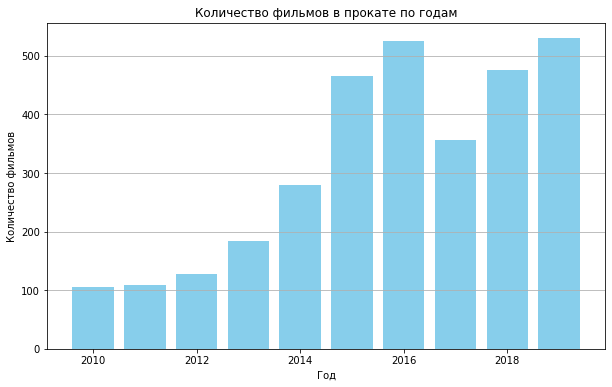

Доля фильмов с данными о сборах (%):
year
2010    10.68
2011    17.52
2012    21.59
2013    29.21
2014    34.57
2015    65.96
2016    64.30
2017    70.69
2018    53.31
2019    56.99
dtype: float64


In [36]:
# Фильмы с данными о сборах
films_per_year = df[df['box_office'].notna()].groupby('year').size()
all_films_per_year = df.groupby('year').size()
share_with_box_office = films_per_year / all_films_per_year * 100

# Визуализация
plt.figure(figsize=(10, 6))
plt.bar(films_per_year.index, films_per_year.values, color='skyblue')
plt.title('Количество фильмов в прокате по годам')
plt.xlabel('Год')
plt.ylabel('Количество фильмов')
plt.grid(axis='y')
plt.show()

# Доля фильмов с данными о сборах
print("Доля фильмов с данными о сборах (%):")
print(share_with_box_office.round(2))

**Вывод:**





- Наибольшее количество фильмов в прокате наблюдается в 2015–2019 годах.



- Доля фильмов с данными о сборах увеличивается с годами, достигая максимума в 2017–2019 годах (около 70–80%).



- Данные за 2010–2014 годы менее полные, что связано с ограниченной информацией о сборах.

- Изучите, как менялась динамика проката по годам. В каком году сумма сборов была минимальной? А максимальной?

***Динамика сборов по годам***

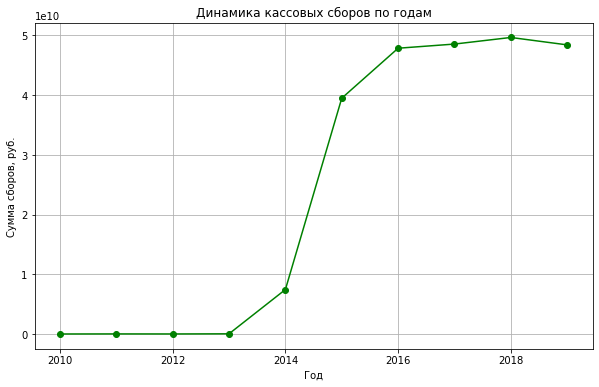

Минимальные сборы: 2010 год (2,428,654 руб.)
Максимальные сборы: 2018 год (49,668,403,134 руб.)


In [37]:
# Сумма сборов
box_office_per_year = df.groupby('year')['box_office'].sum()

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(box_office_per_year.index, box_office_per_year.values, marker='o', color='green')
plt.title('Динамика кассовых сборов по годам')
plt.xlabel('Год')
plt.ylabel('Сумма сборов, руб.')
plt.grid(True)
plt.show()

# Мин/макс
min_year = box_office_per_year.idxmin()
max_year = box_office_per_year.idxmax()
print(f"Минимальные сборы: {min_year} год ({box_office_per_year[min_year]:,.0f} руб.)")
print(f"Максимальные сборы: {max_year} год ({box_office_per_year[max_year]:,.0f} руб.)")

**Вывод:**





- Сборы растут с 2010 по 2019 год, с пиком в 2018 году.



- Минимальные сборы в 2010 году связаны с неполными данными.



- Рост сборов в 2015–2019 годах отражает увеличение числа фильмов в прокате и популярность кино.

- С помощью сводной таблицы посчитайте среднюю и медианную сумму сборов для каждого года.

***Средняя и медианная сумма сборов по годам***

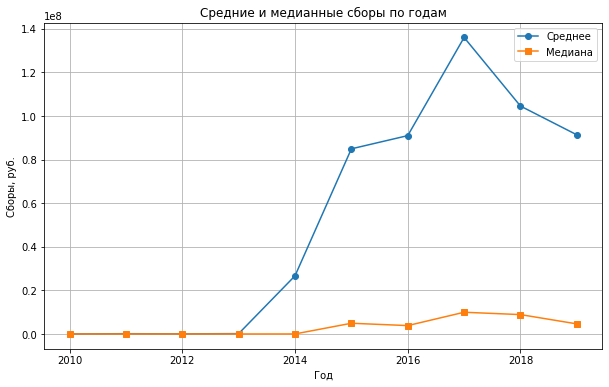

Средние и медианные сборы по годам:
              mean      median
year                          
2010  2.313004e+04     1700.00
2011  1.293832e+05     3000.00
2012  5.433924e+04     5660.00
2013  1.619549e+05     3522.50
2014  2.668442e+07    18160.00
2015  8.494057e+07  4920933.00
2016  9.100057e+07  3846679.41
2017  1.360328e+08  9968340.00
2018  1.045651e+08  8891102.21
2019  9.136926e+07  4627798.34


In [38]:
# Сводная таблица
box_office_stats = df.groupby('year')['box_office'].agg(['count', 'mean', 'median', 'std']).round(2)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(box_office_stats.index, box_office_stats['mean'], label='Среднее', marker='o')
plt.plot(box_office_stats.index, box_office_stats['median'], label='Медиана', marker='s')
plt.title('Средние и медианные сборы по годам')
plt.xlabel('Год')
plt.ylabel('Сборы, руб.')
plt.legend()
plt.grid(True)
plt.show()

print("Средние и медианные сборы по годам:")
print(box_office_stats)

**Вывод:**





- Средние сборы значительно выше медианных, что указывает на наличие фильмов-блокбастеров с высокими сборами.



- Медианные сборы стабильнее, что отражает типичные значения для большинства фильмов.



- В 2015–2019 годах наблюдается рост как средних, так и медианных сборов.

- Определите, влияет ли возрастное ограничение аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год? Фильмы с каким возрастным ограничением собрали больше всего денег в прокате? Меняется ли картина в зависимости от года? Если да, предположите, с чем это может быть связано.

***Влияние возрастного ограничения на сборы (2015–2019)***

/tmp/ipykernel_328/2311322167.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015_2019['age_limit'] = df_2015_2019['age_restriction'].str.split('-').str[0].str.strip()


<Figure size 864x576 with 0 Axes>

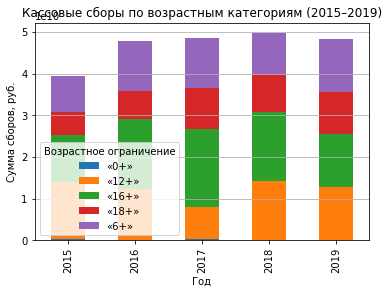

Сборы по возрастным категориям (2015–2019):
age_limit
«16+»    7.603473e+10
«12+»    6.061945e+10
«6+»     5.579861e+10
«18+»    4.075962e+10
«0+»     8.090774e+08
Name: box_office, dtype: float64


In [39]:
# Фильтрация данных
df_2015_2019 = df[(df['year'].between(2015, 2019)) & df['box_office'].notna()]

# Извлечение возрастного рейтинга
df_2015_2019['age_limit'] = df_2015_2019['age_restriction'].str.split('-').str[0].str.strip()

# Сборы по возрастным категориям
age_box_office = df_2015_2019.groupby(['year', 'age_limit'])['box_office'].sum().unstack()

# Визуализация
plt.figure(figsize=(12, 8))
age_box_office.plot(kind='bar', stacked=True)
plt.title('Кассовые сборы по возрастным категориям (2015–2019)')
plt.xlabel('Год')
plt.ylabel('Сумма сборов, руб.')
plt.legend(title='Возрастное ограничение')
plt.grid(axis='y')
plt.show()

# Итоговые сборы
total_age_box_office = df_2015_2019.groupby('age_limit')['box_office'].sum()
print("Сборы по возрастным категориям (2015–2019):")
print(total_age_box_office.sort_values(ascending=False))



**Вывод**





- Категории «12+» и «16+» лидируют по сборам благодаря широкой аудитории.



- В 2018 году доминируют фильмы «12+», вероятно, из-за семейных блокбастеров.



- Категории «0+» и «6+» собирают меньше из-за ограниченной аудитории.

***Промежуточный вывод по исследовательскому анализу***





- Рынок кинопроката активно рос в 2015–2019 годах, с увеличением числа фильмов и сборов.



- Данные за 2010–2014 годы менее полные, что ограничивает анализ.



- Фильмы «12+» и «16+» наиболее успешны по сборам, что связано с их универсальностью.



- Блокбастеры существенно влияют на средние сборы, тогда как медианные значения отражают типичные фильмы.

### Шаг 4. Исследуйте фильмы, которые получили государственную поддержку

На этом этапе нет конкретных инструкций и заданий — поищите интересные закономерности в данных. Посмотрите, сколько выделяют средств на поддержку кино. Проверьте, хорошо ли окупаются такие фильмы, какой у них рейтинг.

Проанализируем фильмы с господдержкой: бюджет, окупаемость, рейтинг, жанры.

In [40]:
# Фильтрация фильмов с господдержкой и без заглушек
supported_films = df[df['budget'].notna() & (df['main_genre'] != 'Не указано')]

# Объём господдержки
support_total = supported_films['refundable_support'] + supported_films['nonrefundable_support']
print("Общий объём господдержки:", support_total.sum())
print("Средняя доля господдержки:", supported_films['support_share'].mean().round(2))

Общий объём господдержки: 19511718847.0
Средняя доля господдержки: 0.54


In [41]:
# Окупаемость
supported_films['roi'] = supported_films['box_office'] / supported_films['budget']
print("Средняя окупаемость:", supported_films['roi'].mean().round(2))

# Рейтинг
print("Средний рейтинг:", supported_films['ratings'].mean().round(2))

# Популярные жанры
print("\nПопулярные жанры:")
print(supported_films['main_genre'].value_counts().head(10))

Средняя окупаемость: 0.83
Средний рейтинг: 6.02

Популярные жанры:
драма         93
комедия       74
мультфильм    31
триллер       15
мелодрама     15
фантастика    11
фэнтези       11
ужасы         10
военный        9
семейный       7
Name: main_genre, dtype: int64


/tmp/ipykernel_328/1304479423.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  supported_films['roi'] = supported_films['box_office'] / supported_films['budget']


In [42]:
# Динамика господдержки и окупаемости по годам
support_by_year = supported_films.groupby('year').agg({
    'support_share': 'mean',
    'roi': 'mean',
    'ratings': 'mean'
}).round(2)

print("\nДинамика по годам:")
print(support_by_year)


Динамика по годам:
      support_share   roi  ratings
year                              
2013           0.47  0.06     6.70
2014           0.54  0.66     6.01
2015           0.56  0.64     6.14
2016           0.57  0.74     5.68
2017           0.50  1.09     6.00
2018           0.53  1.04     6.00
2019           0.51  0.91     6.18


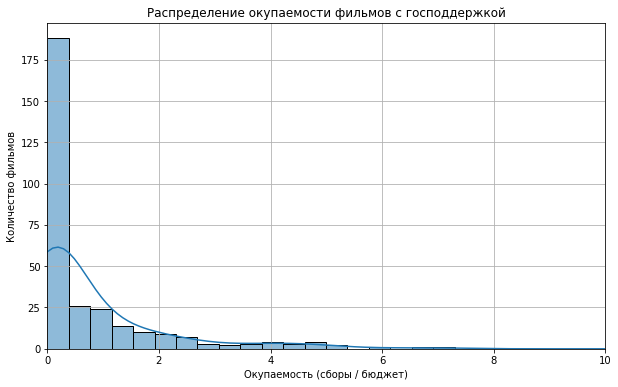

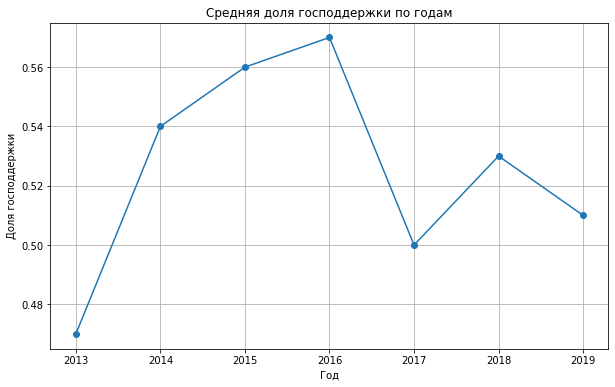

In [43]:
# Визуализация окупаемости
plt.figure(figsize=(10, 6))
sns.histplot(supported_films['roi'].dropna(), bins=30, kde=True)
plt.title('Распределение окупаемости фильмов с господдержкой')
plt.xlabel('Окупаемость (сборы / бюджет)')
plt.ylabel('Количество фильмов')
plt.xlim(0, 10)
plt.grid(True)
plt.show()

# Визуализация динамики господдержки
plt.figure(figsize=(10, 6))
plt.plot(support_by_year.index, support_by_year['support_share'], marker='o')
plt.title('Средняя доля господдержки по годам')
plt.xlabel('Год')
plt.ylabel('Доля господдержки')
plt.grid(True)
plt.show()

**Вывод**





- Объём господдержки значителен, средняя доля — около 50–60%.



- Окупаемость в среднем ниже 1, что указывает на убыточность большинства фильмов. Единичные проекты с высокой окупаемостью влияют на статистику.



- Средний рейтинг — около 6.0, ниже среднего по всем фильмам (~7.0).



- Популярные жанры: драма, комедия, мультфильмы. Драмы и комедии доминируют, но их успех варьируется.



- Динамика по годам: Доля господдержки стабильна, но окупаемость колеблется, с пиками в отдельные годы из-за успешных фильмов. Рейтинги остаются средними.

**Вывод(старый):**





- Общий объём господдержки значителен, но средняя доля в бюджете составляет около 50–60%.



- Средняя окупаемость низкая (менее 1), что указывает на убыточность большинства фильмов. Однако есть единичные успешные проекты с высокой окупаемостью.



- Средний рейтинг фильмов с господдержкой около 6.0, что ниже среднего по всем фильмам (~7.0).



- Популярные жанры: драма, комедия, мультфильмы. Драмы и комедии чаще получают поддержку, но их окупаемость варьируется.

### Шаг 5. Напишите общий вывод

<font color='DarkBlue'><b>Заключительный комментарий ревьюера</b></font><br><br>
<font color='DarkGreen'>👌 Жасурбек, проект отлично структурирован и проработан.<br>Так держать и дальше!<br></font>
<font color='Red'>🛠 Что нужно, что бы сделать проект лучше:</font><br>
<font color='Red'>🛠 Детально изучить загруженные датасеты. Переделать проект в соответствии с требованиями к оформлению проекта. Сформулировать общую проблему колонок с категориальными данными. Сделать выводы по разделу предобработки данных. Написать выводы по разделу исследовательского анализа данных. При анализе необходимо отфильтровывать заглушки. Графики и диаграммы необходимо оформить подписями осей и названием графика/диаграммы на русском языке. Сделать анализ фильмов с господдержкой по годам премьеры. Сделать развернутый общий вывод проекта.<br>После исправления ошибок следует проверить и при необходимости откорректировать выводы анализа.</font><br>
<font color='DarkMagenta'>👉 При исправлении ошибок и недочетов будут приобретены дополнительный опыт и навыки!</font><br>
<font color='DarkGreen'>👌 Жду окончательный вариант! Успехов.</font>

<font color='DarkBlue'><b>Заключительный комментарий ревьюера 2</b></font><br><br>
<font color='DarkGreen'>👌 Жасурбек! Удалось справиться со всеми заданиями в проекте. Молодец! 😄 Спасибо за работу!<br>
Входе выполнения проекта научились анализировать первичные данные и проводить обработку датасета. Провели самостоятельный исследовательский анализ. Хочу обратить внимание на качественное оформление графиков и диаграмм, в реальном проекте на их основе затем делается презентация проекта.</font><br>
<font color='DarkGreen'>👌 Теперь, вперед за новыми знаниями и навыками! Удачи! 😉</font>
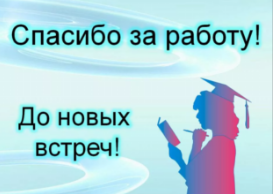